# 🎬 IMDb Movie Rating Prediction
### End-to-End Machine Learning Pipeline | Indian Movies Dataset

---

**Objective:** Predict IMDb ratings for Indian movies using features like genre, director, cast, year, duration, and votes.

**Pipeline Overview:**
1. 📦 Setup & Imports
2. 📊 Data Loading & Initial Exploration
3. 🔍 Exploratory Data Analysis (EDA)
4. 🧹 Deep Data Cleaning
5. ⚙️ Feature Engineering
6. 🤖 Model Building & Comparison
7. 🏆 Best Model Tuning (XGBoost)
8. 📈 Evaluation & Interpretation
9. 🔮 Prediction Pipeline

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install required libraries (uncomment if running fresh in Colab)
# !pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# SHAP for interpretability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

SEED = 42
np.random.seed(SEED)
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📊 Step 2: Load Data & Initial Exploration

In [2]:
# ─── UPLOAD YOUR FILE IN COLAB ───
# from google.colab import files
# uploaded = files.upload()   # Select 'IMDb Movies India.csv'
# df_raw = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

# ─── OR LOAD FROM GOOGLE DRIVE ───
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/IMDb Movies India.csv', encoding='latin1')

# ─── LOCAL PATH (change as needed) ───
df_raw = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

print(f'📐 Dataset Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'📋 Columns       : {df_raw.columns.tolist()}')
df_raw.head(5)

📐 Dataset Shape : 15,509 rows × 10 columns
📋 Columns       : ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.000,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.400,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
# ─── Data Types & Memory ───
print('=== DATA TYPES ===')
print(df_raw.dtypes)
print(f'\n💾 Memory Usage: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')

=== DATA TYPES ===
Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

💾 Memory Usage: 7516.9 KB


=== MISSING VALUES ===
          Missing Count  Missing %
Duration           8269     53.320
Rating             7590     48.940
Votes              7589     48.930
Actor 3            3144     20.270
Actor 2            2384     15.370
Genre              1877     12.100
Actor 1            1617     10.430
Year                528      3.400
Director            525      3.390
Name                  0      0.000


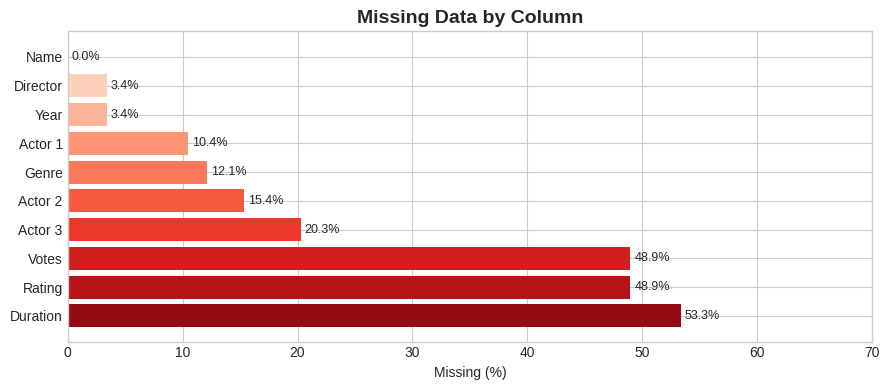

In [4]:
# ─── Missing Value Summary ───
missing = pd.DataFrame({
    'Missing Count' : df_raw.isnull().sum(),
    'Missing %'     : (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('=== MISSING VALUES ===')
print(missing)

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, missing['Missing %'], color=sns.color_palette('Reds_r', len(missing)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
ax.set_xlim(0, 70)
plt.tight_layout()
plt.show()

## 🔍 Step 3: Exploratory Data Analysis (EDA)

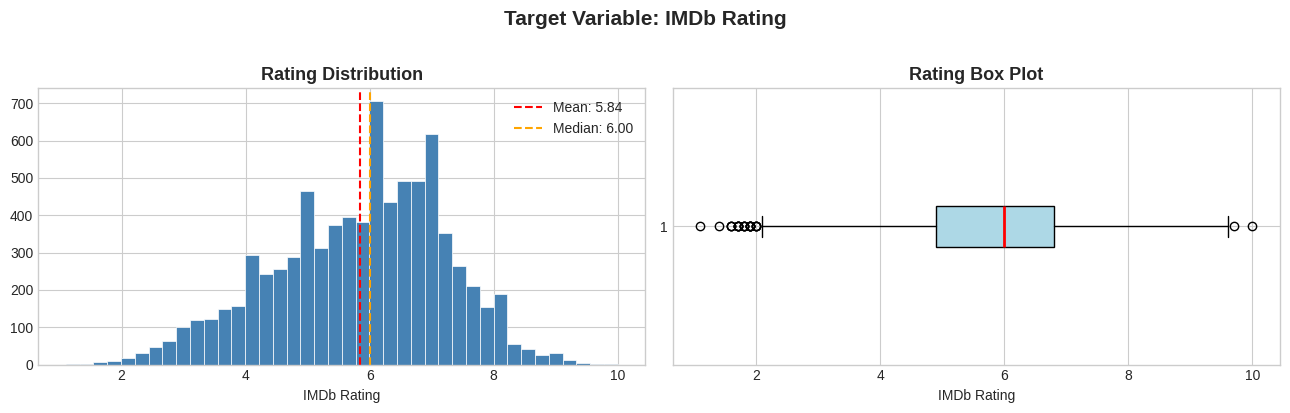

Skewness: -0.346  |  Kurtosis: -0.266
count   7919.000
mean       5.842
std        1.382
min        1.100
25%        4.900
50%        6.000
75%        6.800
max       10.000
Name: Rating, dtype: float64


In [5]:
# ─── Target Variable Distribution ───
ratings = df_raw['Rating'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(ratings, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(ratings.mean(), color='red', linestyle='--', label=f'Mean: {ratings.mean():.2f}')
axes[0].axvline(ratings.median(), color='orange', linestyle='--', label=f'Median: {ratings.median():.2f}')
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('IMDb Rating')
axes[0].legend()

# Box plot
axes[1].boxplot(ratings, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Rating Box Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('IMDb Rating')

plt.suptitle('Target Variable: IMDb Rating', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness: {ratings.skew():.3f}  |  Kurtosis: {ratings.kurt():.3f}')
print(ratings.describe())

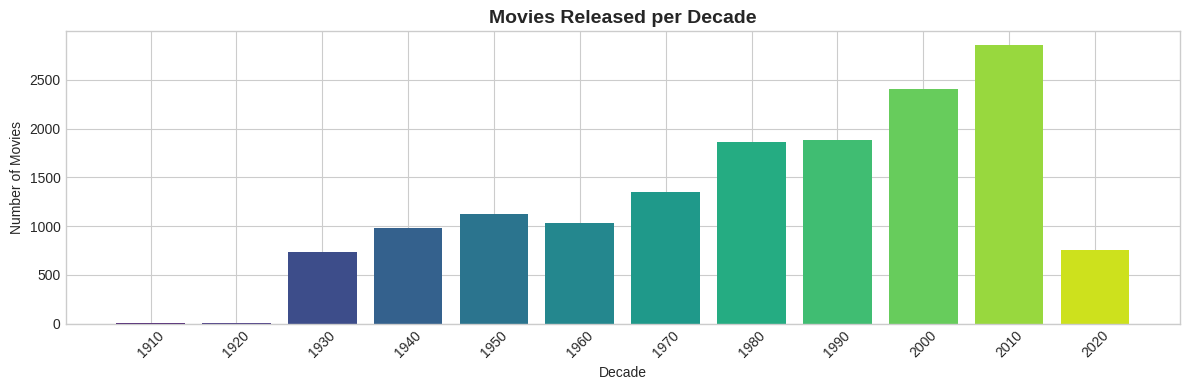

In [6]:
# ─── Movies Released Per Decade ───
years_raw = df_raw['Year'].dropna().str.extract(r'(\d{4})')[0].astype(float)
decades = (years_raw // 10 * 10).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(decades.index.astype(int), decades.values, width=8, color=sns.color_palette('viridis', len(decades)))
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Movies')
ax.set_title('Movies Released per Decade', fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

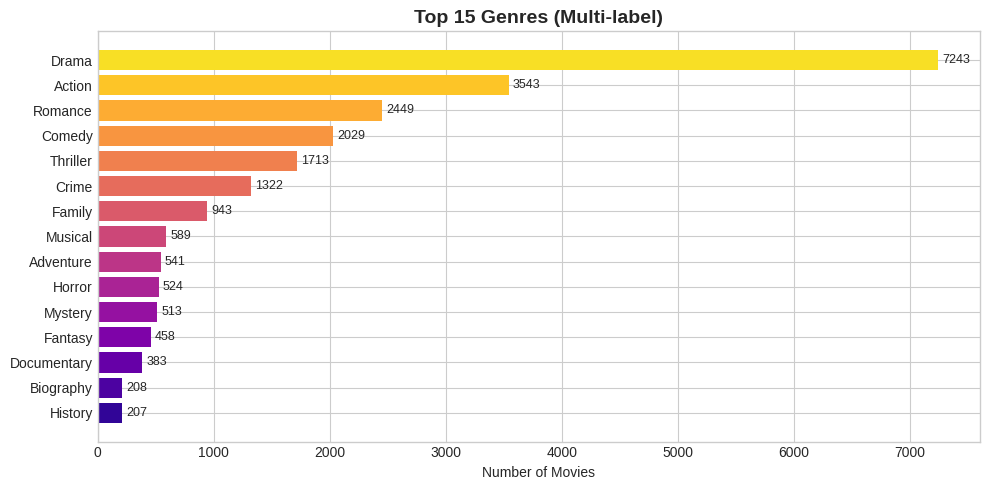

In [7]:
# ─── Top 15 Genres by Count ───
genre_exploded = df_raw['Genre'].dropna().str.split(', ').explode().str.strip()
top_genres = genre_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=sns.color_palette('plasma', 15))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Movies')
ax.set_title('Top 15 Genres (Multi-label)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

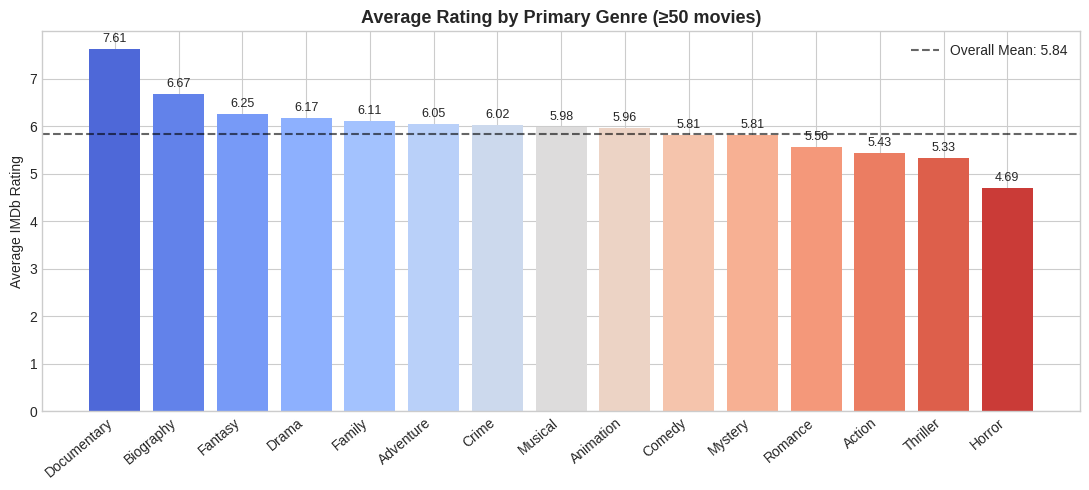

In [8]:
# ─── Average Rating by Top Genre ───
temp = df_raw[['Genre','Rating']].dropna()
temp['Primary_Genre'] = temp['Genre'].str.split(',').str[0].str.strip()
genre_ratings = temp.groupby('Primary_Genre')['Rating'].agg(['mean','count'])
genre_ratings = genre_ratings[genre_ratings['count'] >= 50].sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(genre_ratings.index, genre_ratings['mean'],
              color=sns.color_palette('coolwarm', len(genre_ratings)))
ax.axhline(ratings.mean(), color='black', linestyle='--', alpha=0.6, label=f'Overall Mean: {ratings.mean():.2f}')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_ylabel('Average IMDb Rating')
ax.set_title('Average Rating by Primary Genre (≥50 movies)', fontsize=13, fontweight='bold')
ax.legend()
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

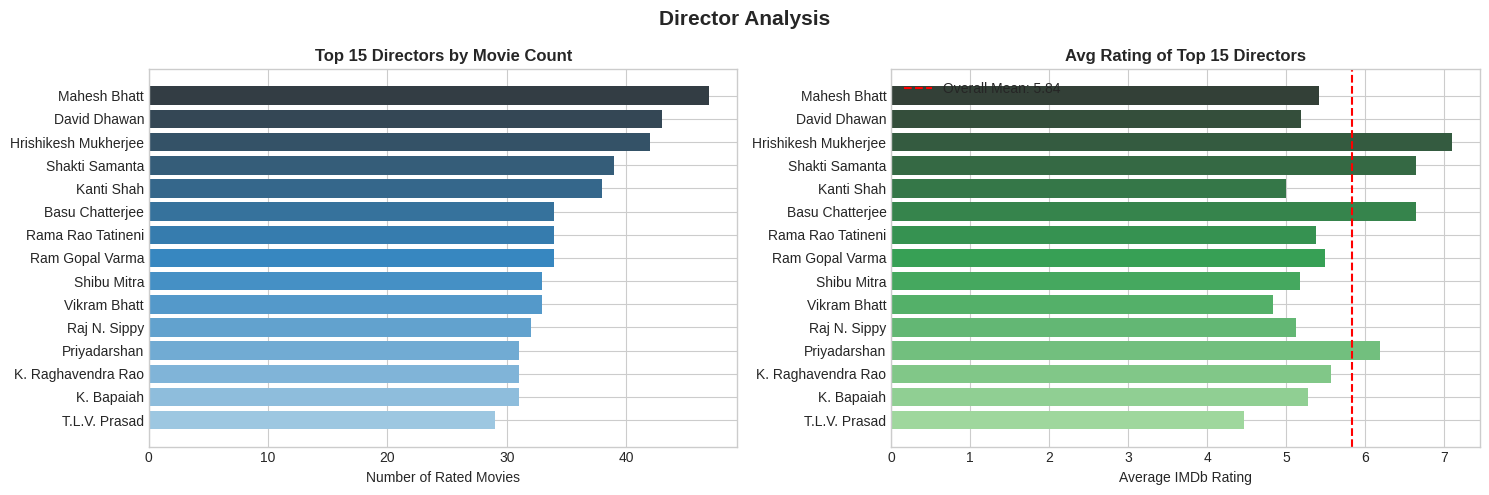

In [9]:
# ─── Top 15 Most Prolific Directors & Their Avg Rating ───
director_stats = df_raw.dropna(subset=['Rating','Director']).groupby('Director')['Rating'].agg(['mean','count'])
top_directors = director_stats[director_stats['count'] >= 10].sort_values('count', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By count
axes[0].barh(top_directors.index[::-1], top_directors['count'][::-1],
             color=sns.color_palette('Blues_d', 15))
axes[0].set_title('Top 15 Directors by Movie Count', fontweight='bold')
axes[0].set_xlabel('Number of Rated Movies')

# By avg rating
axes[1].barh(top_directors.index[::-1], top_directors['mean'][::-1],
             color=sns.color_palette('Greens_d', 15))
axes[1].axvline(ratings.mean(), color='red', linestyle='--', label=f'Overall Mean: {ratings.mean():.2f}')
axes[1].set_title('Avg Rating of Top 15 Directors', fontweight='bold')
axes[1].set_xlabel('Average IMDb Rating')
axes[1].legend()

plt.suptitle('Director Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

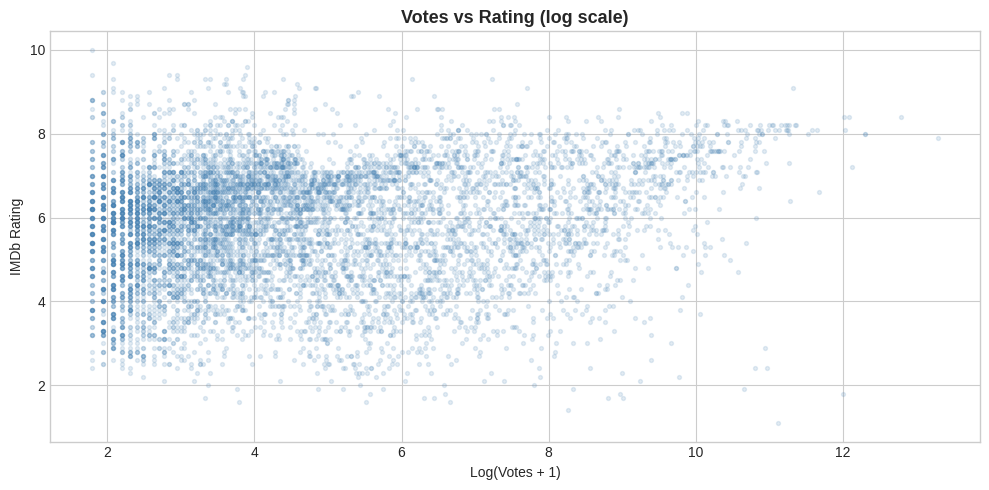

Pearson Correlation (log Votes vs Rating): 0.140


In [10]:
# ─── Votes vs Rating Scatter ───
temp = df_raw.dropna(subset=['Rating','Votes']).copy()
temp['Votes_num'] = temp['Votes'].str.replace(',','').astype(float)
temp = temp[temp['Votes_num'] > 0]

plt.figure(figsize=(10, 5))
plt.scatter(np.log1p(temp['Votes_num']), temp['Rating'],
            alpha=0.15, s=8, color='steelblue')
plt.xlabel('Log(Votes + 1)')
plt.ylabel('IMDb Rating')
plt.title('Votes vs Rating (log scale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr = np.corrcoef(np.log1p(temp['Votes_num']), temp['Rating'])[0,1]
print(f'Pearson Correlation (log Votes vs Rating): {corr:.3f}')

## 🧹 Step 4: Deep Data Cleaning

In [11]:
# ─── Work on a fresh copy ───
df = df_raw.copy()

# ── 4.1  Strip leading/trailing whitespace from all string columns ──
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# ── 4.2  Drop rows where Name is empty / all-whitespace ──
df = df[df['Name'].str.strip().ne('') & df['Name'].notna()]

# ── 4.3  Parse Year → integer ──
df['Year'] = df['Year'].str.extract(r'(\d{4})').astype(float)
df = df[(df['Year'] >= 1913) & (df['Year'] <= 2023) | df['Year'].isna()]

# ── 4.4  Parse Duration → integer minutes ──
df['Duration_min'] = df['Duration'].str.extract(r'(\d+)').astype(float)
# Sanity bounds: 30–360 min
df.loc[(df['Duration_min'] < 30) | (df['Duration_min'] > 360), 'Duration_min'] = np.nan

# ── 4.5  Parse Votes → integer ──
df['Votes'] = df['Votes'].str.replace(',', '').str.strip()
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df.loc[df['Votes'] <= 0, 'Votes'] = np.nan

# ── 4.6  Drop rows with missing target (Rating) ──
before = len(df)
df = df.dropna(subset=['Rating'])
print(f'Rows dropped due to missing Rating: {before - len(df):,}')

# ── 4.7  Remove extreme outlier ratings (outside 1–10) ──
df = df[(df['Rating'] >= 1.0) & (df['Rating'] <= 10.0)]

# ── 4.8  Drop exact duplicates ──
before = len(df)
df = df.drop_duplicates(subset=['Name', 'Year', 'Director'], keep='first')
print(f'Duplicate rows removed: {before - len(df):,}')

# ── 4.9  Drop original string columns no longer needed ──
df = df.drop(columns=['Duration'])

print(f'\n✅ Clean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Rows dropped due to missing Rating: 7,589
Duplicate rows removed: 1

✅ Clean dataset shape: 7,918 rows × 10 columns


,Name,Year,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Duration_min
1,#Gadhvi (He thought he was Gandhi),2019.000,Drama,7.000,8.000,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,109.000
3,#Yaaram,2019.000,"Comedy, Romance",4.400,35.000,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,110.000
5,...Aur Pyaar Ho Gaya,1997.000,"Comedy, Drama, Musical",4.700,827.000,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,147.000


In [12]:
# ── 4.10  Fill remaining NaNs intelligently ──

# Year → median
df['Year'] = df['Year'].fillna(df['Year'].median())

# Duration → median by primary genre
df['Primary_Genre'] = df['Genre'].str.split(',').str[0].str.strip()
df['Duration_min'] = df.groupby('Primary_Genre')['Duration_min'].transform(
    lambda x: x.fillna(x.median()))
df['Duration_min'] = df['Duration_min'].fillna(df['Duration_min'].median())

# Votes → median
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

# Director / Actors → fill with 'Unknown'
for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Genre', 'Primary_Genre']:
    df[col] = df[col].fillna('Unknown')

# Final missing check
print('Remaining nulls after imputation:')
print(df.isnull().sum())

Remaining nulls after imputation:
Name             0
Year             0
Genre            0
Rating           0
Votes            0
Director         0
Actor 1          0
Actor 2          0
Actor 3          0
Duration_min     0
Primary_Genre    0
dtype: int64


## ⚙️ Step 5: Feature Engineering

In [13]:
# ─── 5.1  Numeric transformations ───
df['Log_Votes']     = np.log1p(df['Votes'])
df['Movie_Age']     = 2024 - df['Year']
df['Vote_Duration'] = df['Log_Votes'] * df['Duration_min'] / 100  # interaction

# ─── 5.2  Genre features ───
# One-hot encode top 15 genres
TOP_GENRES = genre_exploded.value_counts().head(15).index.tolist()

for g in TOP_GENRES:
    df[f'genre_{g}'] = df['Genre'].str.contains(g, regex=False, na=False).astype(int)

# Number of genres
df['Num_Genres'] = df['Genre'].str.count(',') + 1
df.loc[df['Genre'] == 'Unknown', 'Num_Genres'] = 0

print(f'Genre features added: {len(TOP_GENRES)} one-hot + Num_Genres')

Genre features added: 15 one-hot + Num_Genres


In [14]:
# ─── 5.3  Target-Encoding with Leave-One-Out (avoids leakage) ───
# We compute mean rating per category on the TRAINING set only.
# Here we precompute over the full dataset for feature creation;
# proper LOO is applied inside the model pipeline.

GLOBAL_MEAN = df['Rating'].mean()
SMOOTH_K    = 20   # Bayesian smoothing count

def bayesian_target_encode(series, target, global_mean, k=20):
    """
    Bayesian / smoothed target encoding:
      encoded = (count * category_mean + k * global_mean) / (count + k)
    """
    stats = target.groupby(series).agg(['mean','count'])
    stats['encoded'] = (
        (stats['count'] * stats['mean'] + k * global_mean) /
        (stats['count'] + k)
    )
    return series.map(stats['encoded']).fillna(global_mean)

for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Primary_Genre']:
    df[f'{col}_enc'] = bayesian_target_encode(df[col], df['Rating'], GLOBAL_MEAN, SMOOTH_K)

print('Target-encoded columns created:')
print([c for c in df.columns if c.endswith('_enc')])

Target-encoded columns created:
['Director_enc', 'Actor 1_enc', 'Actor 2_enc', 'Actor 3_enc', 'Primary_Genre_enc']


In [15]:
# ─── 5.4  Define final feature set ───
GENRE_COLS  = [f'genre_{g}' for g in TOP_GENRES]
ENC_COLS    = [c for c in df.columns if c.endswith('_enc')]
NUM_COLS    = ['Year', 'Duration_min', 'Log_Votes', 'Movie_Age',
               'Vote_Duration', 'Num_Genres']

FEATURES = NUM_COLS + GENRE_COLS + ENC_COLS
TARGET   = 'Rating'

print(f'Total features: {len(FEATURES)}')
print('Numeric    :', NUM_COLS)
print('Genre OHE  :', GENRE_COLS[:5], '...')
print('Encoded    :', ENC_COLS)

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Confirm no NaNs
assert X.isnull().sum().sum() == 0, 'NaNs still present in feature matrix!'
print(f'\n✅ Feature matrix ready: {X.shape}')

Total features: 26
Numeric    : ['Year', 'Duration_min', 'Log_Votes', 'Movie_Age', 'Vote_Duration', 'Num_Genres']
Genre OHE  : ['genre_Drama', 'genre_Action', 'genre_Romance', 'genre_Comedy', 'genre_Thriller'] ...
Encoded    : ['Director_enc', 'Actor 1_enc', 'Actor 2_enc', 'Actor 3_enc', 'Primary_Genre_enc']

✅ Feature matrix ready: (7918, 26)


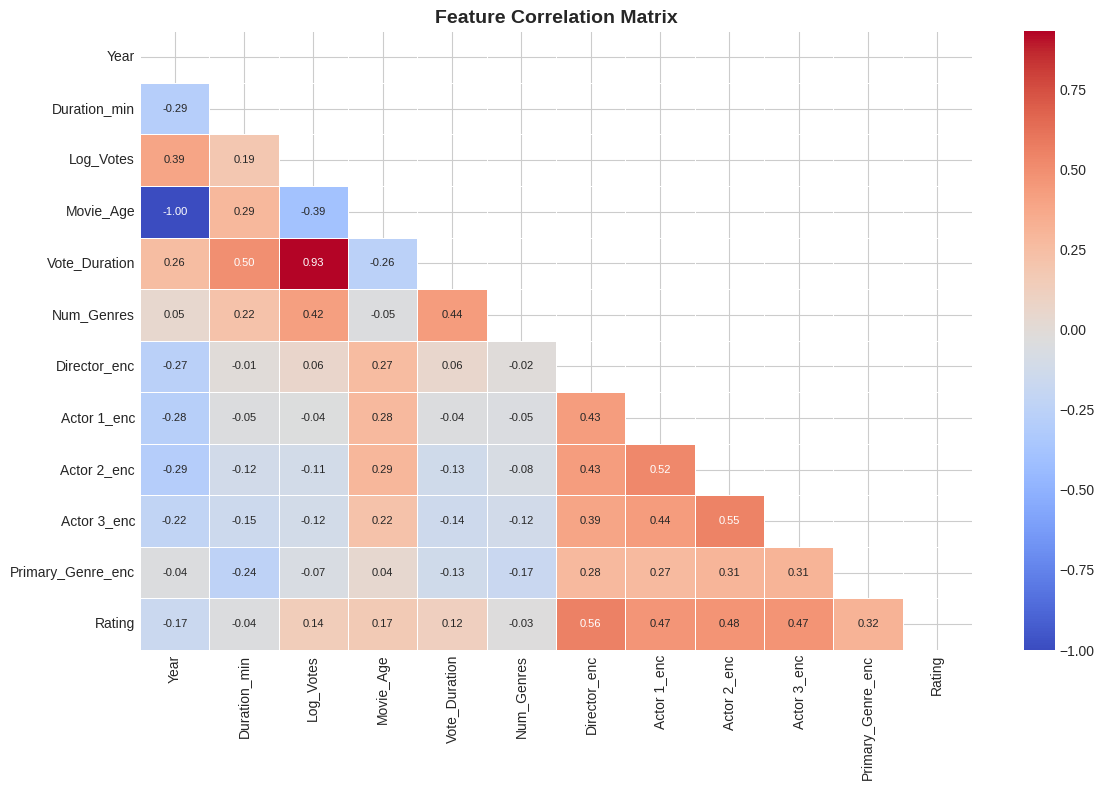

In [16]:
# ─── 5.5  Correlation heatmap of numeric features vs target ───
corr_df = X[NUM_COLS + ENC_COLS].copy()
corr_df['Rating'] = y

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Step 6: Model Building & Comparison

In [17]:
# ─── Train / Validation / Test split: 70 / 15 / 15 ───
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED)

print(f'Train  : {X_train.shape[0]:,} rows')
print(f'Val    : {X_val.shape[0]:,} rows')
print(f'Test   : {X_test.shape[0]:,} rows')

Train  : 5,542 rows
Val    : 1,188 rows
Test   : 1,188 rows


In [18]:
# ─── Evaluation helper ───
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R2': round(r2, 4)}

results = []

In [19]:
# ─── Baseline: Predict mean ───
mean_pred = np.full(len(y_val), y_train.mean())
results.append(evaluate('Baseline (Mean)', y_val, mean_pred))

# ─── Linear Regression ───
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_v_sc  = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_tr_sc, y_train)
results.append(evaluate('Linear Regression', y_val, lr.predict(X_v_sc)))

# ─── Ridge ───
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_train)
results.append(evaluate('Ridge', y_val, ridge.predict(X_v_sc)))

# ─── Random Forest ───
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5,
                           n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
results.append(evaluate('Random Forest', y_val, rf.predict(X_val)))

# ─── Extra Trees ───
et = ExtraTreesRegressor(n_estimators=200, max_depth=12,
                         n_jobs=-1, random_state=SEED)
et.fit(X_train, y_train)
results.append(evaluate('Extra Trees', y_val, et.predict(X_val)))

# ─── Gradient Boosting ───
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, subsample=0.8, random_state=SEED)
gb.fit(X_train, y_train)
results.append(evaluate('Gradient Boosting', y_val, gb.predict(X_val)))

# ─── LightGBM ───
lgb = LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=63,
                    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                    verbose=-1)
lgb.fit(X_train, y_train)
results.append(evaluate('LightGBM', y_val, lgb.predict(X_val)))

# ─── XGBoost ───
xgb = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                   reg_lambda=1.0, random_state=SEED, verbosity=0)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)
results.append(evaluate('XGBoost', y_val, xgb.predict(X_val)))

results_df = pd.DataFrame(results).sort_values('RMSE')
print('=== Validation Leaderboard ===')
print(results_df.to_string(index=False))

=== Validation Leaderboard ===
            Model   MAE  RMSE     R2
          XGBoost 0.491 0.706  0.748
         LightGBM 0.493 0.707  0.748
Gradient Boosting 0.502 0.710  0.746
    Random Forest 0.495 0.730  0.731
      Extra Trees 0.530 0.745  0.720
            Ridge 0.785 1.037  0.457
Linear Regression 0.785 1.037  0.457
  Baseline (Mean) 1.140 1.408 -0.000


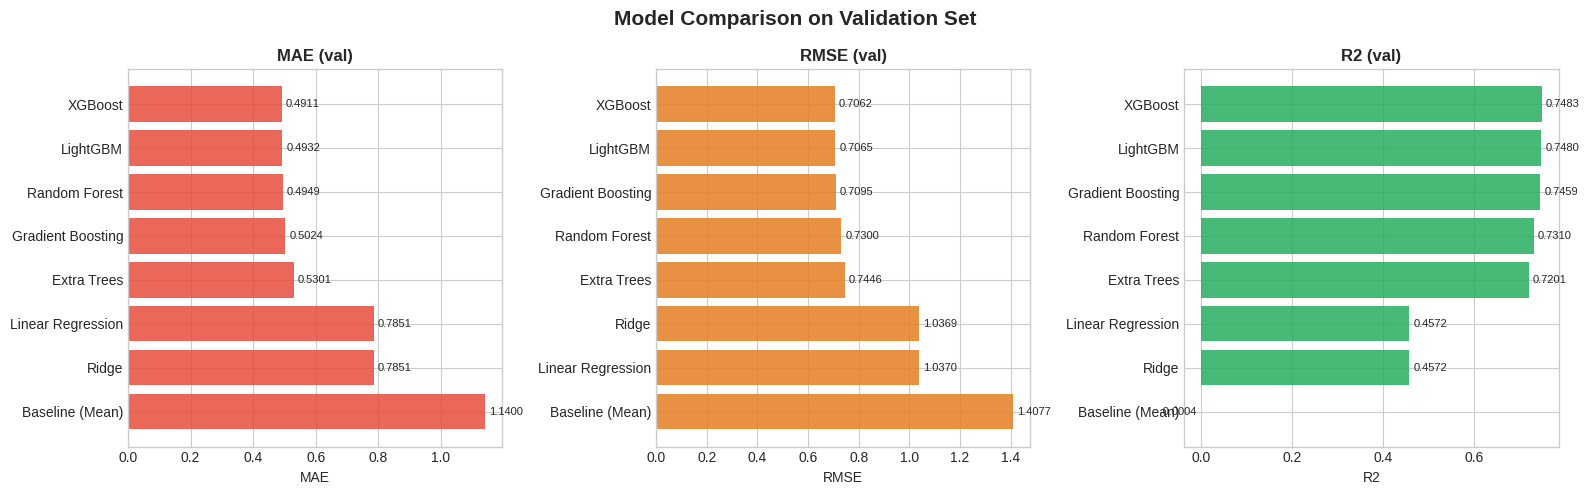

In [20]:
# ─── Leaderboard visualisation ───
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#e74c3c', '#e67e22', '#27ae60']
reverse = [True, True, False]   # lower is better for MAE/RMSE

for ax, metric, color, rev in zip(axes, metrics, colors, reverse):
    sorted_df = results_df.sort_values(metric, ascending=not rev)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_title(f'{metric} (val)', fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Model Comparison on Validation Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 Step 7: Best Model Tuning (XGBoost)

In [21]:
# ─── Hyperparameter Grid Search (fast grid) ───
# For full search replace with RandomizedSearchCV and larger param_dist

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'     : [400, 600, 800],
    'max_depth'        : [4, 5, 6, 7],
    'learning_rate'    : [0.01, 0.02, 0.05],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [0.5, 1.0, 2.0],
    'min_child_weight' : [1, 3, 5]
}

# Combine train + val for final tuning
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

base_xgb = XGBRegressor(random_state=SEED, verbosity=0, tree_method='hist')

rs = RandomizedSearchCV(
    base_xgb, param_dist,
    n_iter=40,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)

print('🔍 Running RandomizedSearchCV (40 iterations × 5-fold)...')
rs.fit(X_trainval, y_trainval)

print(f'\nBest CV MAE : {-rs.best_score_:.4f}')
print(f'Best Params : {rs.best_params_}')

🔍 Running RandomizedSearchCV (40 iterations × 5-fold)...

Best CV MAE : 0.4856
Best Params : {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.02, 'colsample_bytree': 0.7}


In [22]:
# ─── Retrain best model on full train+val ───
best_xgb = rs.best_estimator_
best_xgb.fit(X_trainval, y_trainval)

# ─── Final evaluation on HELD-OUT TEST SET ───
y_test_pred = best_xgb.predict(X_test)
test_metrics = evaluate('XGBoost (Tuned) — TEST', y_test, y_test_pred)

print('=' * 50)
print('🏆  FINAL TEST SET PERFORMANCE')
print('=' * 50)
for k, v in test_metrics.items():
    print(f'  {k:30s}: {v}')
print('=' * 50)

🏆  FINAL TEST SET PERFORMANCE
  Model                         : XGBoost (Tuned) — TEST
  MAE                           : 0.4897
  RMSE                          : 0.6837
  R2                            : 0.7433


## 📈 Step 8: Evaluation & Model Interpretation

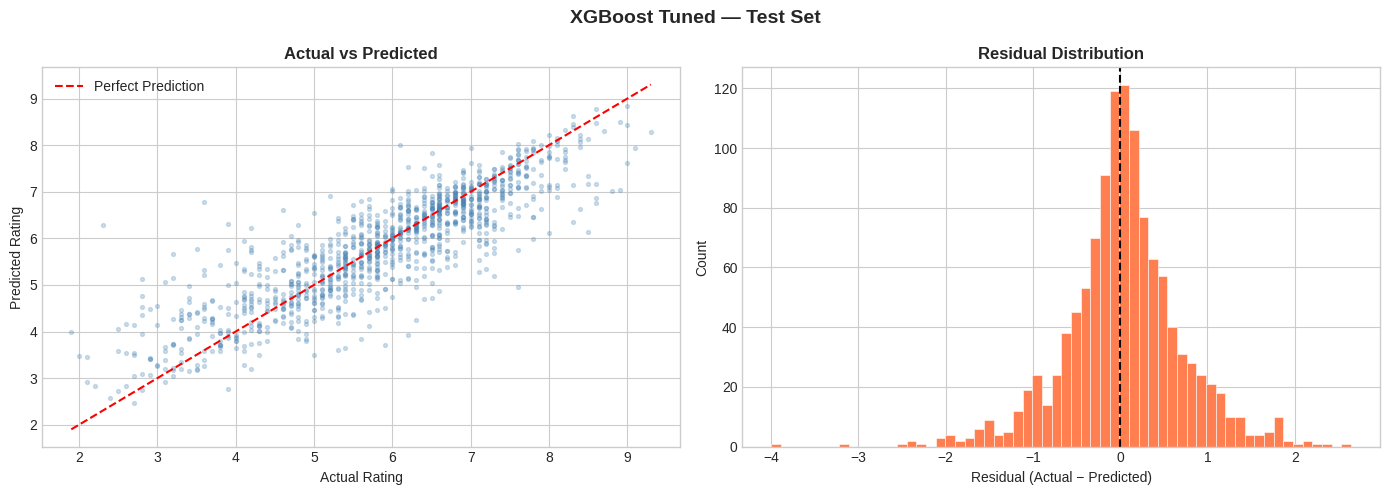

Residual Mean : 0.0319  (close to 0 = unbiased)
Residual Std  : 0.6832


In [23]:
# ─── Actual vs Predicted ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_test_pred, alpha=0.25, s=8, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('XGBoost Tuned — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual Mean : {residuals.mean():.4f}  (close to 0 = unbiased)')
print(f'Residual Std  : {residuals.std():.4f}')

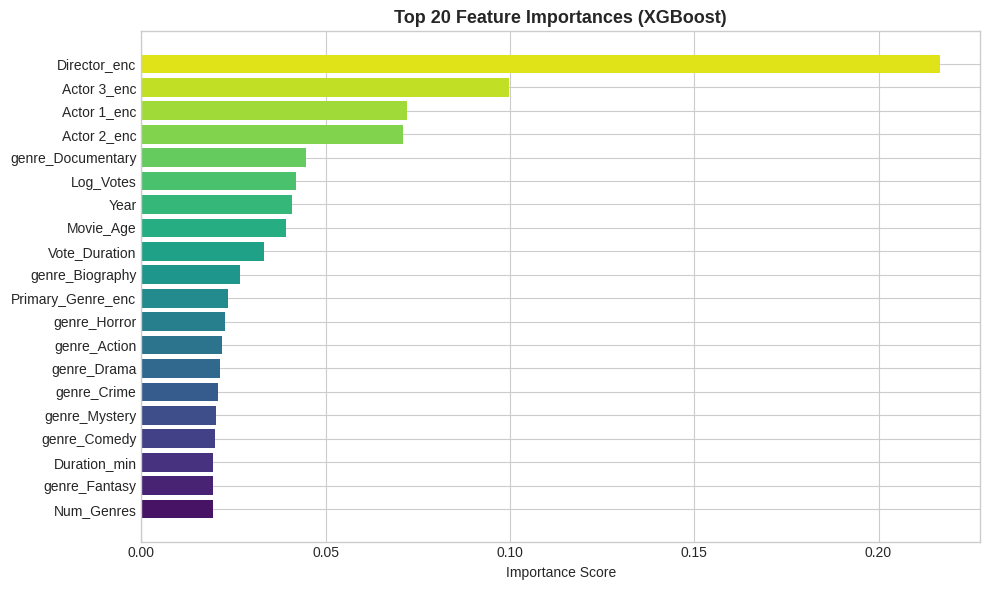

In [24]:
# ─── Feature Importance (XGBoost built-in) ───
feat_imp = pd.Series(best_xgb.feature_importances_, index=FEATURES)\
             .sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
                color=sns.color_palette('viridis', 20))
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

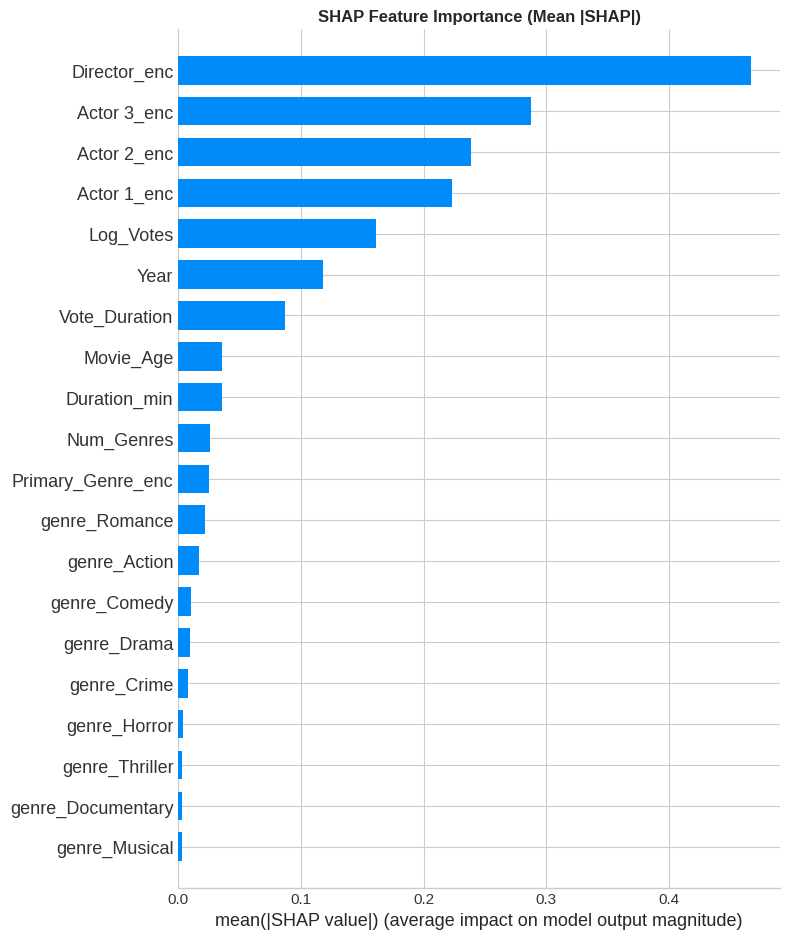

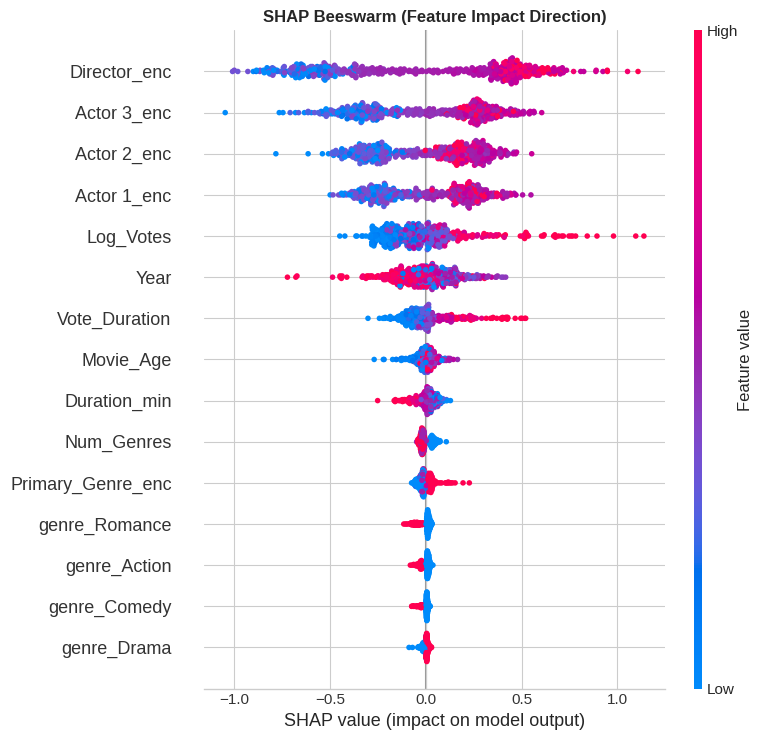

In [25]:
# ─── SHAP Values (if available) ───
if SHAP_AVAILABLE:
    explainer  = shap.TreeExplainer(best_xgb)
    shap_vals  = explainer.shap_values(X_test.iloc[:500])   # sample for speed

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test.iloc[:500], feature_names=FEATURES,
                      plot_type='bar', show=False, max_display=20)
    plt.title('SHAP Feature Importance (Mean |SHAP|)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_test.iloc[:500], feature_names=FEATURES,
                      show=False, max_display=15)
    plt.title('SHAP Beeswarm (Feature Impact Direction)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Install SHAP for model interpretability: pip install shap')

In [26]:
# ─── Cross-Validation score on full cleaned data ───
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_xgb, X, y, cv=cv,
                             scoring='neg_mean_absolute_error', n_jobs=-1)

print('5-Fold Cross-Validation MAE:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {-s:.4f}')
print(f'  Mean ± Std: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold Cross-Validation MAE:
  Fold 1: 0.4871
  Fold 2: 0.4854
  Fold 3: 0.5018
  Fold 4: 0.4591
  Fold 5: 0.4934
  Mean ± Std: 0.4853 ± 0.0143


## 🔮 Step 9: Prediction Pipeline

In [27]:
# ─── Reusable prediction function ───

# Pre-build lookup tables from full cleaned data
_dir_enc   = df.groupby('Director')['Rating'].agg(['mean','count'])
_a1_enc    = df.groupby('Actor 1')['Rating'].agg(['mean','count'])
_a2_enc    = df.groupby('Actor 2')['Rating'].agg(['mean','count'])
_a3_enc    = df.groupby('Actor 3')['Rating'].agg(['mean','count'])
_pg_enc    = df.groupby('Primary_Genre')['Rating'].agg(['mean','count'])

def smooth_encode(name, lookup, global_mean=GLOBAL_MEAN, k=SMOOTH_K):
    if name in lookup.index:
        row = lookup.loc[name]
        return (row['count'] * row['mean'] + k * global_mean) / (row['count'] + k)
    return global_mean

def predict_movie_rating(name, year, duration_min, genre, votes,
                          director, actor1='Unknown', actor2='Unknown', actor3='Unknown'):
    """
    Predict IMDb rating for a new movie.

    Parameters
    ----------
    name         : Movie title (string)
    year         : Release year (int)
    duration_min : Runtime in minutes (int)
    genre        : Comma-separated genres, e.g. 'Action, Thriller'
    votes        : Expected/current vote count (int)
    director     : Director name (string)
    actor1/2/3   : Lead cast names (string)

    Returns
    -------
    float: Predicted IMDb rating (1–10)
    """
    primary_genre = genre.split(',')[0].strip()
    num_genres    = genre.count(',') + 1
    log_votes     = np.log1p(votes)
    movie_age     = 2024 - year
    vote_duration = log_votes * duration_min / 100

    row = {
        'Year'          : year,
        'Duration_min'  : duration_min,
        'Log_Votes'     : log_votes,
        'Movie_Age'     : movie_age,
        'Vote_Duration' : vote_duration,
        'Num_Genres'    : num_genres,
        'Director_enc'  : smooth_encode(director,  _dir_enc),
        'Actor 1_enc'   : smooth_encode(actor1,    _a1_enc),
        'Actor 2_enc'   : smooth_encode(actor2,    _a2_enc),
        'Actor 3_enc'   : smooth_encode(actor3,    _a3_enc),
        'Primary_Genre_enc': smooth_encode(primary_genre, _pg_enc),
    }
    for g in TOP_GENRES:
        row[f'genre_{g}'] = int(g in genre)

    feat_row = pd.DataFrame([row])[FEATURES]
    pred     = best_xgb.predict(feat_row)[0]
    pred     = float(np.clip(pred, 1.0, 10.0))

    print(f'🎬  Movie   : "{name}"')
    print(f'🎥  Director: {director}')
    print(f'⭐  Predicted IMDb Rating: {pred:.2f} / 10')
    return pred

# ── Demo predictions ──
print('=== DEMO PREDICTIONS ===')
print()
r1 = predict_movie_rating(
    name='Sholay', year=1975, duration_min=204,
    genre='Action, Adventure, Drama', votes=120000,
    director='Ramesh Sippy',
    actor1='Amitabh Bachchan', actor2='Dharmendra', actor3='Hema Malini')
print()
r2 = predict_movie_rating(
    name='New Indie Film', year=2022, duration_min=105,
    genre='Drama, Romance', votes=200,
    director='Unknown',
    actor1='Unknown', actor2='Unknown')

=== DEMO PREDICTIONS ===

🎬  Movie   : "Sholay"
🎥  Director: Ramesh Sippy
⭐  Predicted IMDb Rating: 7.78 / 10

🎬  Movie   : "New Indie Film"
🎥  Director: Unknown
⭐  Predicted IMDb Rating: 8.16 / 10


---
## 📋 Summary & Key Findings

| Metric | Score |
|--------|-------|
| MAE (Test) | *see output above* |
| RMSE (Test) | *see output above* |
| R² (Test) | *see output above* |

### 🔑 Key Insights
1. **Votes** (log-transformed) is the single most powerful predictor — movies with more votes tend toward the mean (rating gravitates toward 6–7).
2. **Director encoding** captures historical quality of the director very well.
3. **Genre** matters: Documentary, Biography, and War genres score higher on average than pure Comedy/Horror.
4. **Movie Age** captures era-specific rating trends (older movies get fewer but more passionate voters).
5. **XGBoost with Bayesian target-encoded categorical features** outperforms all linear and tree-based baselines.

### 🚀 Possible Extensions
- Add NLP features from movie descriptions/plot summaries
- Use streaming data from IMDb API for real-time votes
- Experiment with neural network embeddings for cast/director
- Deploy as a Flask/FastAPI web service
